In [112]:
import os, sys, importlib, pathlib
import pandas as pd
from pathlib import Path
sys.path.append (os.path.abspath(".."))
# my utils
from utils import fa
from utils import modeling
from utils import preprocess_listings
from utils.preprocess_listings import desc_catORnum

# 标准版存档V0：

LABELS_EN=[
            'open to different cultures', 'cosmopolitan','international view', 'cultural exchange',
            'personal life', 'life experiences', 'divers interests', 'hobbies', 'enjoy life',
            'meet new people', 'welcoming', 'friendly', 'sociable', 'interpersonal interaction',
            'thoughtful service', 'attentive to needs', 'willing to help', 'responsive',
            'fan of Airbnb', 'Airbnb community','love Airbnb', 'travel with Airbnb'
        ]
DICT_FACTOR_ITEMS={"ouverture":['open to different cultures', 'cosmopolitan','international view', 'cultural exchange'],
                   "authenticité":['personal life', 'life experiences', 'divers interests', 'hobbies', 'enjoy life'],
                   "sociabilité":['meet new people', 'welcoming', 'friendly', 'sociable', 'interpersonal interaction'],
                   "auto_promotion":['thoughtful service', 'attentive to needs', 'willing to help', 'responsive'],
                   "exemplarité":['fan of Airbnb', 'Airbnb community','love Airbnb', 'travel with Airbnb']}


In [141]:
path_df="../data_processed\listings_tactics_bio_vis-paris_london-2306_2406.csv"
df_all=pd.read_csv(path_df)
print(df_all.shape)

C:\Users\yeliu\AppData\Local\Temp\ipykernel_2424\3453220627.py:2: DtypeWarning: Columns (68) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all=pd.read_csv(path_df)


(187851, 124)


In [114]:
# df_all.rename(columns={'len':'text_length'}, inplace=True)
# df_all.to_csv(path_df, index=False)

In [142]:
df_all.columns.to_list()

['id',
 'listing_url',
 'scrape_id',
 'last_scraped',
 'source',
 'name',
 'description',
 'neighborhood_overview',
 'picture_url',
 'host_id',
 'host_url',
 'host_name',
 'host_since',
 'host_location',
 'host_about',
 'host_response_time',
 'host_response_rate',
 'host_acceptance_rate',
 'host_is_superhost',
 'host_thumbnail_url',
 'host_picture_url',
 'host_neighbourhood',
 'host_listings_count',
 'host_total_listings_count',
 'host_verifications',
 'host_has_profile_pic',
 'host_identity_verified',
 'neighbourhood',
 'neighbourhood_cleansed',
 'neighbourhood_group_cleansed',
 'latitude',
 'longitude',
 'property_type',
 'room_type',
 'accommodates',
 'bathrooms',
 'bathrooms_text',
 'bedrooms',
 'beds',
 'amenities',
 'price',
 'minimum_nights',
 'maximum_nights',
 'minimum_minimum_nights',
 'maximum_minimum_nights',
 'minimum_maximum_nights',
 'maximum_maximum_nights',
 'minimum_nights_avg_ntm',
 'maximum_nights_avg_ntm',
 'calendar_updated',
 'has_availability',
 'availability_30

In [144]:
# # DROPNA no pic match?
df=df_all.copy()
print(df[['host_has_profile_pic', 'has_face', 'host_picture_type',"is_smiling"]].value_counts(dropna=False),"\n")
df_dropnoface=df[df["has_face"].notna()]
print(len(df_all),len(df_dropnoface))

host_has_profile_pic  has_face  host_picture_type  is_smiling
t                     0.0       no_person          0.0           55515
                      1.0       pro_style          0.0           37747
                                life_style         0.0           34152
                                pro_style          1.0           29267
                                life_style         1.0           22634
f                     NaN       NaN                NaN            7264
t                     NaN       NaN                NaN            1271
f                     0.0       no_person          0.0               1
Name: count, dtype: int64 

187851 179316


In [145]:
# FILLNQ no pic match?
df=df_all.copy()
df['has_face']=df["has_face"].fillna(0)
df['host_picture_type']=df["host_picture_type"].fillna("no_person")
df['is_smiling']=df["is_smiling"].fillna(0)
df_fillnoface=df.copy()
print(df_fillnoface[['host_has_profile_pic', 'has_face',"host_picture_type",'is_smiling']].value_counts(dropna=False),"\n")
print(len(df_all),len(df))

host_has_profile_pic  has_face  host_picture_type  is_smiling
t                     0.0       no_person          0.0           56786
                      1.0       pro_style          0.0           37747
                                life_style         0.0           34152
                                pro_style          1.0           29267
                                life_style         1.0           22634
f                     0.0       no_person          0.0            7265
Name: count, dtype: int64 

187851 187851


In [146]:
vars_tactics=[
    "ouverture", "authenticité","sociabilité","auto_promotion","exemplarité", 
    "host_picture_type","is_smiling", "smile_score"
    ]

df[vars_tactics]=df[vars_tactics].fillna(0)
print(df[vars_tactics].isna().value_counts(dropna=False))

# vars_person=["age_class","gender"]
# df[vars_person]=df[vars_person].fillna('unk')


ouverture  authenticité  sociabilité  auto_promotion  exemplarité  host_picture_type  is_smiling  smile_score
False      False         False        False           False        False              False       False          187851
Name: count, dtype: int64


## ols: y=numeric tactic

In [119]:
importlib.reload(modeling)
from utils.modeling import write_formula,build_model

import statsmodels.api as sm
import statsmodels.formula.api as smf


# C(host_is_superhost)
# C(host_has_profile_pic)

x_vars=["host_identity_verified", "host_has_profile_pic",         
    "review_scores_rating", #"has_rating", "number_of_reviews",
    "years_since_host","professional_host",'host_is_superhost', ##'calculated_host_listings_count',
    # 'status_changed', 'old_host_sp_changed',# "is_changed"
    "lang", "text_length",
    "price",
    "availability_90",#*
    "room_type", "instant_bookable", #'is_within_1km',
]  


tactics_bio=["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]
tactics_pic=["host_picture_type","is_smiling"]

group_vars=["in_paris","in_2024"]

# smile_score coef 过小!
            # "ouverture + authenticité + sociabilité + auto_promotion + exemplarité +"
            # "C(host_picture_type) + is_smiling + "
            
formula= (" is_smiling~ C(host_identity_verified)  + review_scores_rating + has_rating + number_of_reviews_ltm +"
            "C(host_is_superhost) +"
            "years_since_host + professional_host + "
            "text_length + C(lang) +"
            "price  + availability_90 + C(room_type) + C(instant_bookable) + "
            "in_paris * in_2024"
)
model=smf.ols(formula, data=df).fit(cov_type="HC1")#robust standard errors

summary=model.summary()
print(summary)


# authenticité, sociabilité(r²小), auto_promotion 在jo期间显著积极
# ouverture, exemplarité 不显著

                            OLS Regression Results                            
Dep. Variable:             is_smiling   R-squared:                       0.060
Model:                            OLS   Adj. R-squared:                  0.060
Method:                 Least Squares   F-statistic:                     679.9
Date:                Mon, 30 Mar 2026   Prob (F-statistic):               0.00
Time:                        17:09:25   Log-Likelihood:            -1.0712e+05
No. Observations:              179316   AIC:                         2.143e+05
Df Residuals:                  179295   BIC:                         2.145e+05
Df Model:                          20                                         
Covariance Type:                  HC1                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

## ols: y=categorial tactic

In [120]:
importlib.reload(modeling)
from utils.modeling import write_formula,build_model

import statsmodels.api as sm
import statsmodels.formula.api as smf


# C(host_is_superhost)
# C(host_has_profile_pic)
x_vars=["host_identity_verified", "host_has_profile_pic",         
    "review_scores_rating", #"has_rating", "number_of_reviews",
    "years_since_host","professional_host",'host_is_superhost', ##'calculated_host_listings_count',
    # 'status_changed', 'old_host_sp_changed',# "is_changed"
    "lang", "text_length",
    "price",
    "availability_90",#*
    "room_type", "instant_bookable", #'is_within_1km',
]  
tactics_bio=["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]
tactics_pic=["host_picture_type","is_smiling"]
group_vars=["in_paris","in_2024"]


# host_picture_type=> dummy
df["pic_no_person"] = (df["host_picture_type"]=="no_person").astype(int)
df["pic_pro_style"] = (df["host_picture_type"]=="pro_style").astype(int)
df["pic_life_style"] = (df["host_picture_type"]=="life_style").astype(int)
df['host_is_superhost']=df['host_is_superhost'].apply(lambda x: 1 if x=="t" else 0)
print(df['host_is_superhost'].value_counts(dropna=False))

def stars(p):
    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.1:
        return "*"
    else:
        return ""
    
    
# smile_score coef 过小!

tactics_vars=["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité",
              "pic_no_person", "pic_pro_style", "pic_life_style", "is_smiling",
              "host_is_superhost"]
results = []

for var in tactics_vars:
    # print(f"{var}".center(100,"="))
    formula= (f" {var}~ C(host_identity_verified)  + review_scores_rating + has_rating + number_of_reviews_ltm +"
                "C(host_is_superhost) +"
                "years_since_host + professional_host + "
                "text_length + C(lang) +"
                "price  + availability_90 + C(room_type) + C(instant_bookable) + "
                "in_paris * in_2024"
    )
    model=smf.ols(formula, data=df).fit(cov_type="HC1")#robust standard errors
    
    
    coef = model.params["in_paris:in_2024"]
    se = model.bse["in_paris:in_2024"]
    pval = model.pvalues["in_paris:in_2024"]
    
    results.append({
        "variable": var,
        "coef": coef,
        "se": se,
        "pval": pval,
        "stars": stars(pval),
        "ci_low": coef - 1.96 * se,
        "ci_high": coef + 1.96 * se
    })

import pandas as pd
results_df = pd.DataFrame(results)
# 只有auth, socio, promo显著变化，且是显著提升！
# 更多选取有人物的头像！更多微笑！

host_is_superhost
0    143720
1     35596
Name: count, dtype: int64


In [122]:
display(results_df)

,variable,coef,se,pval,stars,ci_low,ci_high
0,ouverture,-5.223421e-03,6.277499e-03,4.053602e-01,,-1.752732e-02,7.080477e-03
1,authenticité,3.996200e-02,6.566680e-03,1.160770e-09,***,2.709131e-02,5.283269e-02
2,sociabilité,2.825797e-02,6.773088e-03,3.018110e-05,***,1.498272e-02,4.153322e-02
3,auto_promotion,1.881823e-02,6.196115e-03,2.388646e-03,***,6.673848e-03,3.096262e-02
4,exemplarité,7.683850e-03,6.391663e-03,2.292986e-01,,-4.843809e-03,2.021151e-02
5,pic_no_person,-3.424771e-02,4.012241e-03,1.391829e-17,***,-4.211170e-02,-2.638372e-02
6,pic_pro_style,1.072367e-02,4.569323e-03,1.893120e-02,**,1.767793e-03,1.967954e-02
7,pic_life_style,2.352404e-02,4.436840e-03,1.145520e-07,***,1.482784e-02,3.222025e-02
8,is_smiling,4.378155e-02,4.267861e-03,1.084567e-24,***,3.541654e-02,5.214656e-02
9,host_is_superhost,2.718745e-15,2.999877e-15,3.647847e-01,,-3.161013e-15,8.598504e-15


In [157]:
colors[1] if "*" in results_df.iloc[0]['star'] else colors[0]

KeyError: 'star'

[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765), (1.0, 0.4980392156862745, 0.054901960784313725)]


<Figure size 640x480 with 0 Axes>

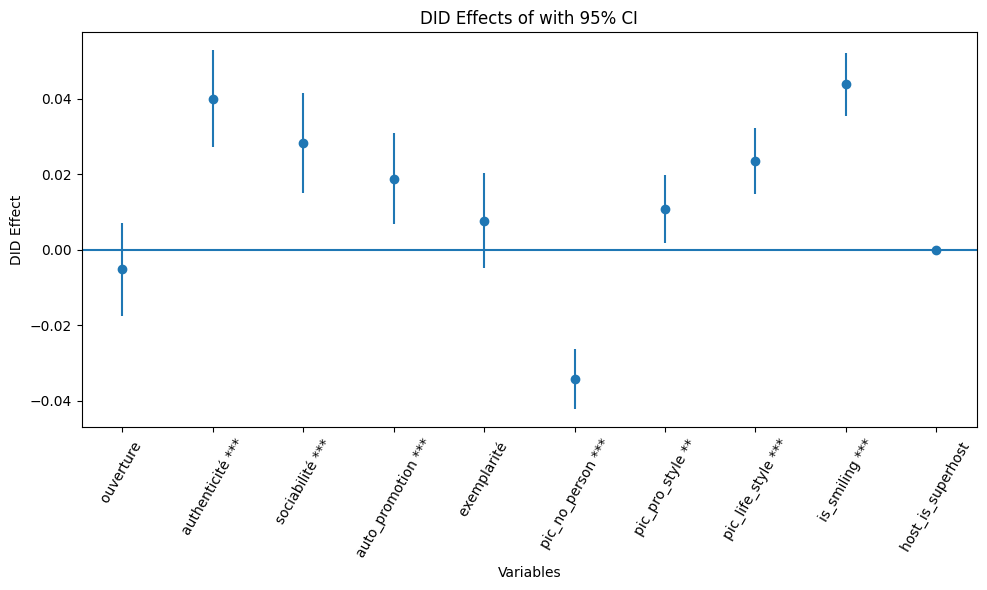

In [159]:
## did effect
import pandas as pd
import matplotlib.pyplot as plt

results_df['label']=results_df['variable']+" "+results_df['stars']
# colors=list(plt.cm.tab10.colors[:2])
# print(colors)

plt.figure()
plt.figure(figsize=(10,6))
plt.errorbar(
    results_df["label"],
    results_df["coef"],
    yerr=[results_df["coef"] - results_df["ci_low"],
          results_df["ci_high"] - results_df["coef"]],
    fmt='o', 
)
plt.axhline(0)  # 0线（是否显著）
plt.xlabel("Variables")
plt.ylabel("DID Effect")
plt.title("DID Effects of with 95% CI")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

## ols: y=booking_rate

In [164]:
## q : number_of_reviews_ltm? bad ctrl?

df_dropnoface[['number_of_reviews_ltm','booking_rate_l90d']].describe()



,number_of_reviews_ltm,booking_rate_l90d
count,179316.000000,179316.000000
mean,8.952826,0.133637
std,15.773427,0.238960
min,0.000000,0.000000
25%,0.000000,0.000000
50%,3.000000,0.033333
75%,11.000000,0.140625
max,852.000000,1.000000


In [163]:
# basic: booking90 ~ ctrl + bio + pic + city*time
importlib.reload(modeling)
from utils.modeling import write_formula,build_model

import statsmodels.api as sm
import statsmodels.formula.api as smf


# C(host_is_superhost)
# C(host_has_profile_pic)

x_vars=["host_identity_verified", "host_has_profile_pic",         
    "review_scores_rating", #"has_rating", "number_of_reviews",
    "years_since_host","professional_host",'host_is_superhost', ##'calculated_host_listings_count',
    # 'status_changed', 'old_host_sp_changed',# "is_changed"
    "lang", "len",
    "price",
    "availability_90",#*
    "room_type", "instant_bookable", #'is_within_1km',
    
    "ouverture", "authenticité","sociabilité","auto_promotion","exemplarité", 
    "host_picture_type","is_smiling"
]  
tactics_vars=["in_paris","in_2024"]

# smile_score coef 过小!

formula= ("booking_rate_l90d ~ C(host_identity_verified)  + review_scores_rating + has_rating + "
            "C(host_is_superhost) +"
            "years_since_host + professional_host + "
            "text_length + C(lang) +"
            "price  + availability_90 + C(room_type) + C(instant_bookable) + "
            "ouverture + authenticité + sociabilité + auto_promotion + exemplarité +"
            "C(host_picture_type) + is_smiling + "
            "in_paris * in_2024"
)
model=smf.ols(formula, data=df_dropnoface).fit()
summary=model.summary()
print(summary)

                            OLS Regression Results                            
Dep. Variable:      booking_rate_l90d   R-squared:                       0.317
Model:                            OLS   Adj. R-squared:                  0.317
Method:                 Least Squares   F-statistic:                     1571.
Date:                Mon, 30 Mar 2026   Prob (F-statistic):               0.00
Time:                        20:38:09   Log-Likelihood:                 15098.
No. Observations:               91337   AIC:                        -3.014e+04
Df Residuals:                   91309   BIC:                        -2.988e+04
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

In [ ]:
## ps.tactics_host* in_paris:in_2024
# R2比不交互时下降

importlib.reload(modeling)
from utils.modeling import write_formula,build_model

import statsmodels.api as sm
import statsmodels.formula.api as smf


# C(host_is_superhost)
# C(host_has_profile_pic)

x_vars=["host_identity_verified", "host_has_profile_pic",         
    "review_scores_rating", #"has_rating", "number_of_reviews",
    "years_since_host","professional_host",'host_is_superhost', ##'calculated_host_listings_count',
    # 'status_changed', 'old_host_sp_changed',# "is_changed"
    "lang", "len",
    "price",
    "availability_90",#*
    "room_type", "instant_bookable", #'is_within_1km',
    
    "ouverture", "authenticité","sociabilité","auto_promotion","exemplarité", 
    "host_picture_type","is_smiling"
]  
tactics_vars=["in_paris","in_2024"]

# smile_score coef 过小!

formula= ("booking_rate_l90d ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
        #   "number_of_reviews_ltm+ "
        "years_since_host + professional_host + "
        "text_length + C(lang) +"
        "price  + availability_90 + C(room_type) + C(instant_bookable) + "
        "(ouverture + authenticité + sociabilité + auto_promotion + exemplarité +C(host_picture_type) + is_smiling + C(host_is_superhost))*in_paris*in_2024"
)
model=smf.ols(formula, data=df_dropnoface).fit()
summary=model.summary()
print(summary)

In [168]:
# tactics_host* in_paris*in_2024
## ps.# tactics_host* in_paris:in_2024，R2比不交互时下降

importlib.reload(modeling)
from utils.modeling import write_formula,build_model

import statsmodels.api as sm
import statsmodels.formula.api as smf


# C(host_is_superhost)
# C(host_has_profile_pic)

x_vars=["host_identity_verified", "host_has_profile_pic",         
    "review_scores_rating", #"has_rating", "number_of_reviews",
    "years_since_host","professional_host",'host_is_superhost', ##'calculated_host_listings_count',
    # 'status_changed', 'old_host_sp_changed',# "is_changed"
    "lang", "len",
    "price",
    "availability_90",#*
    "room_type", "instant_bookable", #'is_within_1km',
    
    "ouverture", "authenticité","sociabilité","auto_promotion","exemplarité", 
    "host_picture_type","is_smiling"
]  
tactics_vars=["in_paris","in_2024"]

# smile_score coef 过小!

formula= ("booking_rate_l90d ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
        #   "number_of_reviews_ltm+ "
        "years_since_host + professional_host + "
        "text_length + C(lang) +"
        "price  + availability_90 + C(room_type) + C(instant_bookable) + "
        "(ouverture + authenticité + sociabilité + auto_promotion + exemplarité +C(host_picture_type) + is_smiling + C(host_is_superhost))*in_paris*in_2024"
)
model=smf.ols(formula, data=df_dropnoface).fit()
summary=model.summary()
print(summary)

                            OLS Regression Results                            
Dep. Variable:      booking_rate_l90d   R-squared:                       0.323
Model:                            OLS   Adj. R-squared:                  0.323
Method:                 Least Squares   F-statistic:                     806.9
Date:                Mon, 30 Mar 2026   Prob (F-statistic):               0.00
Time:                        20:56:26   Log-Likelihood:                 15494.
No. Observations:               91337   AIC:                        -3.088e+04
Df Residuals:                   91282   BIC:                        -3.036e+04
Df Model:                          54                                         
Covariance Type:            nonrobust                                         
                                                         coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------

## ols : 有number_of_reviews版本，关键变量coef变化不大

In [ ]:
# basci model 但ctrl中加上 number_of_reviews_ltm
importlib.reload(modeling)
from utils.modeling import write_formula,build_model

import statsmodels.api as sm
import statsmodels.formula.api as smf


# C(host_is_superhost)
# C(host_has_profile_pic)

x_vars=["host_identity_verified", "host_has_profile_pic",         
    "review_scores_rating", #"has_rating", "number_of_reviews",
    "years_since_host","professional_host",'host_is_superhost', ##'calculated_host_listings_count',
    # 'status_changed', 'old_host_sp_changed',# "is_changed"
    "lang", "len",
    "price",
    "availability_90",#*
    "room_type", "instant_bookable", #'is_within_1km',
    
    "ouverture", "authenticité","sociabilité","auto_promotion","exemplarité", 
    "host_picture_type","is_smiling"
]  
tactics_vars=["in_paris","in_2024"]

# smile_score coef 过小!
##++
formula= ("booking_rate_l90d ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
        "number_of_reviews_ltm + "
        "C(host_is_superhost) +"
        "years_since_host + professional_host + "
        "text_length + C(lang) +"
        "price  + availability_90 + C(room_type) + C(instant_bookable) + "
        "ouverture + authenticité + sociabilité + auto_promotion + exemplarité +"
        "C(host_picture_type) + is_smiling + "
        "in_paris * in_2024"
)

model=smf.ols(formula, data=df).fit()
summary=model.summary()
print(summary)

                            OLS Regression Results                            
Dep. Variable:      booking_rate_l90d   R-squared:                       0.427
Model:                            OLS   Adj. R-squared:                  0.427
Method:                 Least Squares   F-statistic:                     5002.
Date:                Mon, 30 Mar 2026   Prob (F-statistic):               0.00
Time:                        20:57:25   Log-Likelihood:                 56242.
No. Observations:              187851   AIC:                        -1.124e+05
Df Residuals:                  187822   BIC:                        -1.121e+05
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

In [ ]:
# interaction model + number_of_reviews_ltm
# tactics_host* in_paris*in_2024

## ps.# tactics_host* in_paris:in_2024，R2比不交互时下降

importlib.reload(modeling)
from utils.modeling import write_formula,build_model

import statsmodels.api as sm
import statsmodels.formula.api as smf


# C(host_is_superhost)
# C(host_has_profile_pic)

x_vars=["host_identity_verified", "host_has_profile_pic",         
    "review_scores_rating", #"has_rating", "number_of_reviews",
    "years_since_host","professional_host",'host_is_superhost', ##'calculated_host_listings_count',
    # 'status_changed', 'old_host_sp_changed',# "is_changed"
    "lang", "len",
    "price",
    "availability_90",#*
    "room_type", "instant_bookable", #'is_within_1km',
    
    "ouverture", "authenticité","sociabilité","auto_promotion","exemplarité", 
    "host_picture_type","is_smiling"
]  
tactics_vars=["in_paris","in_2024"]

# smile_score coef 过小!

formula= ("booking_rate_l90d ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
        "number_of_reviews_ltm+ "
        "years_since_host + professional_host + "
        "text_length + C(lang) +"
        "price  + availability_90 + C(room_type) + C(instant_bookable) + "
        "(ouverture + authenticité + sociabilité + auto_promotion + exemplarité +C(host_picture_type) + is_smiling + C(host_is_superhost))*in_paris*in_2024"
)
model=smf.ols(formula, data=df_dropnoface).fit()
summary=model.summary()
print(summary)

                            OLS Regression Results                            
Dep. Variable:      booking_rate_l90d   R-squared:                       0.446
Model:                            OLS   Adj. R-squared:                  0.446
Method:                 Least Squares   F-statistic:                     1338.
Date:                Mon, 30 Mar 2026   Prob (F-statistic):               0.00
Time:                        21:08:49   Log-Likelihood:                 24666.
No. Observations:               91337   AIC:                        -4.922e+04
Df Residuals:                   91281   BIC:                        -4.869e+04
Df Model:                          55                                         
Covariance Type:            nonrobust                                         
                                                         coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------

In [177]:
## 每一组的真实effect
import numpy as np
import pandas as pd
from itertools import product

def get_did_marginal_effect(
    model, 
    key_var,
    paris_var="in_paris",
    time_var="in_2024"
):
    """
    计算 key_var 在四个 DID 组中的边际效应
    """

    def p_to_sig(p):
        if p < 0.001: return '***'
        elif p < 0.01: return '**'
        elif p < 0.05: return '*'
        elif p < 0.1: return '.'
        else: return ''

    params = model.params
    param_names = params.index.tolist()

    rows = []

    # 四种组合
    for p, t in product([0,1], [0,1]):

        lin_comb = np.zeros(len(params))

        # 主效应
        if key_var in param_names:
            lin_comb[param_names.index(key_var)] = 1

        # key_var × paris
        term = f"{key_var}:{paris_var}"
        if term in param_names:
            lin_comb[param_names.index(term)] = p

        # key_var × time
        term = f"{key_var}:{time_var}"
        if term in param_names:
            lin_comb[param_names.index(term)] = t

        # triple interaction
        term = f"{key_var}:{paris_var}:{time_var}"
        if term in param_names:
            lin_comb[param_names.index(term)] = p * t

        # t-test
        t_res = model.t_test(lin_comb)

        rows.append({
            "in_paris": p,
            "in_2024": t,
            "group": f"Paris={p}, 2024={t}",
            "coef": float(t_res.effect),
            "se": float(t_res.sd),
            "t": float(t_res.tvalue),
            "pval": float(t_res.pvalue),
            "sig": p_to_sig(float(t_res.pvalue))
        })

    return pd.DataFrame(rows)


In [185]:
tactics=[ "ouverture", "authenticité","sociabilité","auto_promotion","exemplarité", 
    # "host_picture_type","is_smiling"
    ]
for var in tactics:
    print(f"{var}".center(100,'-'))
    res = get_did_marginal_effect(model, var)
    display(res)

---------------------------------------------ouverture----------------------------------------------


C:\Users\yeliu\AppData\Local\Temp\ipykernel_2424\3615403734.py:59: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "coef": float(t_res.effect),
C:\Users\yeliu\AppData\Local\Temp\ipykernel_2424\3615403734.py:60: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "se": float(t_res.sd),
C:\Users\yeliu\AppData\Local\Temp\ipykernel_2424\3615403734.py:61: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "t": float(t_res.tvalue),


,in_paris,in_2024,group,coef,se,t,pval,sig
0,0,0,"Paris=0, 2024=0",-0.000095,0.001589,-0.059631,0.952449,
1,0,1,"Paris=0, 2024=1",0.003326,0.001525,2.180615,0.029214,*
2,1,0,"Paris=1, 2024=0",-0.003911,0.001873,-2.088524,0.036753,*
3,1,1,"Paris=1, 2024=1",-0.001920,0.001494,-1.285340,0.198677,


--------------------------------------------authenticité--------------------------------------------


C:\Users\yeliu\AppData\Local\Temp\ipykernel_2424\3615403734.py:59: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "coef": float(t_res.effect),
C:\Users\yeliu\AppData\Local\Temp\ipykernel_2424\3615403734.py:60: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "se": float(t_res.sd),
C:\Users\yeliu\AppData\Local\Temp\ipykernel_2424\3615403734.py:61: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "t": float(t_res.tvalue),


...

C:\Users\yeliu\AppData\Local\Temp\ipykernel_2424\3615403734.py:59: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "coef": float(t_res.effect),
C:\Users\yeliu\AppData\Local\Temp\ipykernel_2424\3615403734.py:60: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "se": float(t_res.sd),
C:\Users\yeliu\AppData\Local\Temp\ipykernel_2424\3615403734.py:61: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "t": float(t_res.tvalue),


,in_paris,in_2024,group,coef,se,t,pval,sig
0,0,0,"Paris=0, 2024=0",-0.008820,0.001589,-5.548968,2.881552e-08,***
1,0,1,"Paris=0, 2024=1",0.000382,0.001566,0.243741,8.074323e-01,
2,1,0,"Paris=1, 2024=0",-0.013522,0.002044,-6.615301,3.728333e-11,***
3,1,1,"Paris=1, 2024=1",0.005096,0.001629,3.128507,1.757519e-03,**


--------------------------------------------exemplarité---------------------------------------------


C:\Users\yeliu\AppData\Local\Temp\ipykernel_2424\3615403734.py:59: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "coef": float(t_res.effect),
C:\Users\yeliu\AppData\Local\Temp\ipykernel_2424\3615403734.py:60: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "se": float(t_res.sd),
C:\Users\yeliu\AppData\Local\Temp\ipykernel_2424\3615403734.py:61: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "t": float(t_res.tvalue),


,in_paris,in_2024,group,coef,se,t,pval,sig
0,0,0,"Paris=0, 2024=0",0.009734,0.001532,6.353324,2.116999e-10,***
1,0,1,"Paris=0, 2024=1",0.001132,0.001417,0.798790,4.244142e-01,
2,1,0,"Paris=1, 2024=0",0.006366,0.001773,3.590022,3.308231e-04,***
3,1,1,"Paris=1, 2024=1",-0.002516,0.001352,-1.860067,6.287925e-02,.


In [186]:
# for categorial vars:
# for level in ["pro_style", "life_style","no_person"]:
#     print(f"{level}".center(100,'-'))
#     var = f"C(host_picture_type)[T.{level}]"
#     res = get_did_marginal_effect(model, var)
#     display(res)

In [188]:
## plot

import matplotlib.pyplot as plt

plt.figure()
plot_df=df_dropnoface.copy()

for tactic in tactics_bio:
    # sub = plot_df[plot_df["tactic"] == tactic]
    sub=plot_df.copy()
    x = range(len(sub))
    
    plt.errorbar(
        x,
        sub["coef"],
        yerr=1.96 * sub["se"],
        marker='o',
        label=tactic
    )

plt.xticks(
    [0,1,2,3],
    ["London 2023", "London 2024", "Paris 2023", "Paris 2024"],
    rotation=20
)

plt.axhline(0)
plt.title("Marginal Effect of Tactics on Booking Rate")
plt.ylabel("Effect on booking_rate_l90d")

plt.legend()
plt.show()

KeyError: 'coef'

<Figure size 640x480 with 0 Axes>

In [6]:
importlib.reload(modeling)
from utils.modeling import modeling_main,build_model

#-------------------------------vars------------------------------------

x_vars=["host_identity_verified", "host_has_profile_pic",         
    "review_scores_rating", #"has_rating", "number_of_reviews",
    "years_since_host","professional_host",'host_is_superhost', ##'calculated_host_listings_count',
    # 'status_changed', 'old_host_sp_changed',# "is_changed"
    "lang", "len",
    "price",
    "availability_90",#*
    "room_type", "instant_bookable", #'is_within_1km',
    
    "ouverture", "authenticité","sociabilité","auto_promotion","exemplarité", 
    "host_picture_type","is_smiling"
]  
tactics_vars=["is_paris","in_2024"]

modeling_main(df_input=df_all, 
            x_vars=x_vars, 
            y_var="booking_rate_l90d", 
            key_vars=tactics_vars, 
            group_col=None,#"host_is_superhost',#==stauts_changed+sp_changed
            output_folder=None,
            to_fillna0=True,
            run_vif=True,
            # save_models_summary=False,  
            save_models_table=False,
            save_plots=False,
            ndigits=4
        )

=============================================check data=============================================
[INFO] fillna in key cols!`

========================================check output folder=========================================
================================================vif=================================================
+key_vars ; - group_cols
remove key_vars in x_vars
Final x_vars_ctrl :['host_identity_verified', 'host_has_profile_pic', 'review_scores_rating', 'years_since_host', 'professional_host', 'host_is_superhost', 'lang', 'len', 'price', 'availability_90', 'room_type', 'instant_bookable', 'ouverture', 'authenticité', 'sociabilité', 'auto_promotion', 'exemplarité', 'host_picture_type', 'is_smiling']

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) + C(host_picture_type) + review_scores_rating + years_since_host + professional_host + len + price + availabilit

,Variables,VIF,Niveau_colinearite
0,Intercept,91561.521721,***
1,C(host_identity_verified)[T.t],1.017968,*
2,C(host_has_profile_pic)[T.t],1.000178,*
3,C(host_is_superhost)[T.t],1.095642,*
4,C(lang)[T.fr],1.926281,*
5,C(lang)[T.no_text],1.008223,*
6,C(lang)[T.other_langs],1.038891,*
7,C(room_type)[T.Hotel room],1.042722,*
8,C(room_type)[T.Private room],1.167226,*
9,C(room_type)[T.Shared room],1.007452,*



 ============================================basic model============================================= 

[NUMBER CHECK1] x_vars:19, x_vars_ctrl:19
['host_identity_verified', 'host_has_profile_pic', 'review_scores_rating', 'years_since_host', 'professional_host', 'host_is_superhost', 'lang', 'len', 'price', 'availability_90', 'room_type', 'instant_bookable', 'ouverture', 'authenticité', 'sociabilité', 'auto_promotion', 'exemplarité', 'host_picture_type', 'is_smiling', 'booking_rate_l90d']
-key_vars ; - group_cols
Final x_vars_ctrl :['host_identity_verified', 'host_has_profile_pic', 'review_scores_rating', 'years_since_host', 'professional_host', 'host_is_superhost', 'lang', 'len', 'price', 'availability_90', 'room_type', 'instant_bookable', 'ouverture', 'authenticité', 'sociabilité', 'auto_promotion', 'exemplarité', 'host_picture_type', 'is_smiling']

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type)

TypeError: 'in <string>' requires string as left operand, not NoneType